# Intrusion Detection — Network IDS
### Detectron AI · Module 07

This notebook builds a simulated network connection log dataset and trains a
**Decision Tree classifier** to flag intrusions, comparing it against the rule-based
signature detector used in the live web demo (which mirrors how tools like Snort and
early Network IDS systems combine signatures with statistical thresholds).


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

np.random.seed(5)


## 1. Simulate a labeled connection log dataset

(Structured loosely like the classic NSL-KDD intrusion detection dataset's feature set.)

In [2]:
n_normal = 500
n_attack = 100

normal = pd.DataFrame({
    "failed_logins": np.random.poisson(0.3, n_normal),
    "port": np.random.choice([80, 443, 22, 3306], n_normal),
    "bytes_transferred": np.random.normal(2_000_000, 1_500_000, n_normal).clip(1000, None),
    "connections_per_sec": np.random.poisson(2, n_normal),
    "label": 0
})

attack = pd.DataFrame({
    "failed_logins": np.random.poisson(6, n_attack),
    "port": np.random.choice([23, 21, 3389, 22], n_attack),
    "bytes_transferred": np.random.normal(450_000_000, 200_000_000, n_attack).clip(1000, None),
    "connections_per_sec": np.random.poisson(45, n_attack),
    "label": 1
})

df = pd.concat([normal, attack], ignore_index=True).sample(frac=1, random_state=1).reset_index(drop=True)
df.describe()


,failed_logins,port,bytes_transferred,connections_per_sec,label
count,600.000000,600.000000,6.000000e+02,600.000000,600.000000
mean,1.276667,881.921667,7.479106e+07,9.075000,0.166667
std,2.364905,1330.616225,1.815173e+08,16.243947,0.372989
min,0.000000,21.000000,1.000000e+03,0.000000,0.000000
25%,0.000000,22.000000,1.313345e+06,1.000000,0.000000
50%,0.000000,80.000000,2.407926e+06,2.000000,0.000000
75%,1.000000,443.000000,4.013682e+06,4.000000,0.000000
max,12.000000,3389.000000,7.996612e+08,64.000000,1.000000


## 2. Train a Decision Tree classifier

In [3]:
features = ["failed_logins", "port", "bytes_transferred", "connections_per_sec"]
X, y = df[features], df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

clf = DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=42)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)

print(classification_report(y_test, pred, target_names=["benign", "intrusion"]))


              precision    recall  f1-score   support

      benign       1.00      1.00      1.00       125
   intrusion       1.00      1.00      1.00        25

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



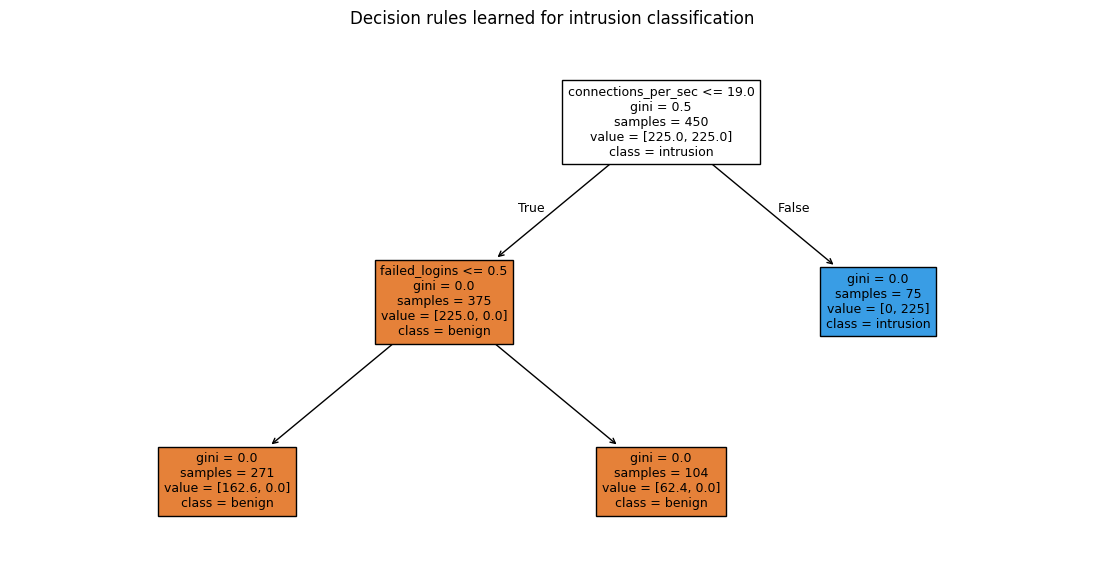

In [4]:
plt.figure(figsize=(14,7))
plot_tree(clf, feature_names=features, class_names=["benign","intrusion"], filled=True, fontsize=9)
plt.title("Decision rules learned for intrusion classification")
plt.show()


## 3. Rule-based signature detector (matches the live web demo)

In [5]:
def analyze_connection(failed_logins, port, bytes_transferred, connections_per_sec, known_malicious_ip=False):
    risk = 0
    flags = []
    if failed_logins >= 5:
        risk += 35; flags.append(f"Brute-force pattern ({failed_logins} failed logins)")
    if port in (23, 21):
        risk += 15; flags.append(f"Legacy insecure protocol (port {port})")
    if bytes_transferred > 500_000_000:
        risk += 25; flags.append(f"Abnormal data volume ({bytes_transferred/1e6:.0f} MB)")
    if connections_per_sec >= 50:
        risk += 30; flags.append(f"Possible DoS/scan pattern ({connections_per_sec} conn/sec)")
    if known_malicious_ip:
        risk += 40; flags.append("Known malicious source (threat-intel match)")
    risk = min(100, risk)
    verdict = "intrusion detected" if risk >= 50 else "suspicious" if risk >= 20 else "benign"
    return risk, verdict, flags

risk, verdict, flags = analyze_connection(failed_logins=9, port=23, bytes_transferred=1_200_000,
                                           connections_per_sec=4, known_malicious_ip=False)
print(f"Risk: {risk}/100 -> {verdict.upper()}")
for f in flags:
    print(" -", f)


Risk: 50/100 -> INTRUSION DETECTED
 - Brute-force pattern (9 failed logins)
 - Legacy insecure protocol (port 23)


## Notes

- The Decision Tree learns statistical thresholds directly from labeled traffic,
  while the rule-based version encodes known attack signatures (brute force, DoS,
  insecure protocols, threat-intel matches) — production IDS like Snort/Suricata
  combine both: signature rules for known attacks, anomaly/ML detection for novel ones.
- Real-world datasets for this task include **NSL-KDD** and **CICIDS2017**, both
  publicly available for more advanced experimentation.
